<a href="https://colab.research.google.com/github/Yaswanthgangireddy/House_analysis/blob/main/XYlofy_AI_week_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 1 — Data Loading & Exploration

In [ ]:
import pandas as pd

df = pd.read_csv("/content/House _Dataset.zip")

print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nFirst 10 Rows:")
display(df.head(10))

Dataset Shape:
(545, 13)

Columns:
Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

First 10 Rows:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


Task 2 — Data Cleaning

In [ ]:
# Check missing values

print("Missing Values:")
print(df.isnull().sum())

# Check duplicate rows

print("\nDuplicate Rows:")
print(df.duplicated().sum())

# Remove duplicates

df = df.drop_duplicates()

print("\nDataset Shape After Removing Duplicates:")
print(df.shape)

Missing Values:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Duplicate Rows:
0

Dataset Shape After Removing Duplicates:
(545, 13)


In [ ]:
# Find categorical columns

categorical_cols = df.select_dtypes(include=['object']).columns

print("Categorical Columns:")
print(categorical_cols)

# Convert categorical columns

df = pd.get_dummies(df,
                    columns=categorical_cols,
                    drop_first=True)

print("\nNew Dataset Shape:")
print(df.shape)

display(df.head(10))

Categorical Columns:
Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')

New Dataset Shape:
(545, 14)


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False
5,10850000,7500,3,3,1,2,True,False,True,False,True,True,True,False
6,10150000,8580,4,3,4,2,True,False,False,False,True,True,True,False
7,10150000,16200,5,3,2,0,True,False,False,False,False,False,False,True
8,9870000,8100,4,1,2,2,True,True,True,False,True,True,False,False
9,9800000,5750,3,2,4,1,True,True,False,False,True,True,False,True


Task 3: Exploratory Data Analysis (EDA)

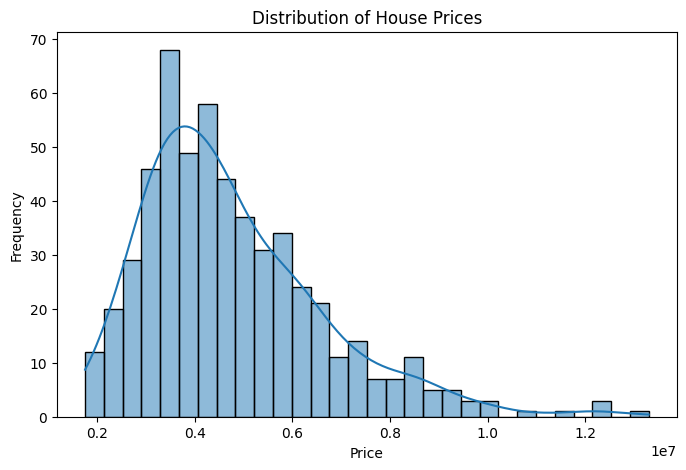

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(df['price'], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

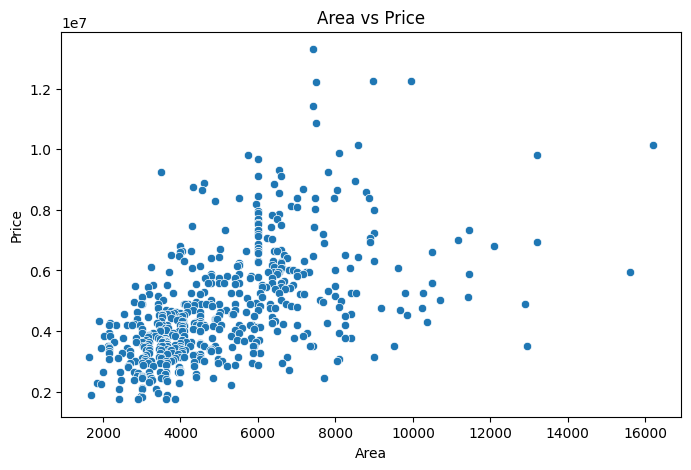

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=df['area'], y=df['price'])

plt.title("Area vs Price")
plt.xlabel("Area")
plt.ylabel("Price")

plt.show()

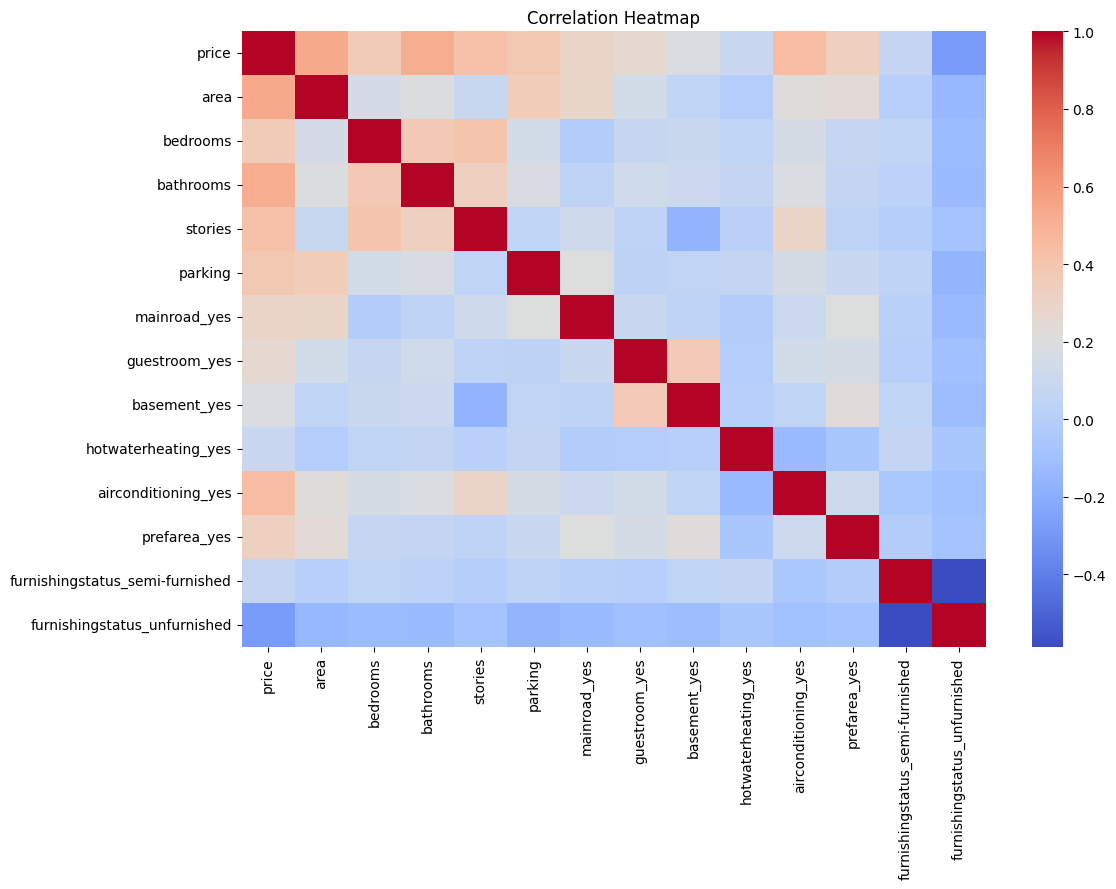

In [ ]:
plt.figure(figsize=(12,8))

corr_matrix = df.corr()

sns.heatmap(corr_matrix,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
plt.savefig("chart_name.png")

<Figure size 640x480 with 0 Axes>

Task 4: Model Building

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (436, 13)
Testing Data Shape: (109, 13)


In [ ]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Linear Regression Model Trained Successfully")

Linear Regression Model Trained Successfully


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [ ]:
comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred_rf
})

comparison.head(10)

,Actual Price,Predicted Price
0,4060000,5377680.00
1,6650000,7287070.00
2,3710000,3747528.75
3,6440000,4502120.00
4,2800000,3748885.00
5,4900000,3432660.00
6,5250000,5070240.00
7,4543000,5050080.00
8,2450000,2572220.00
9,3353000,2822893.50


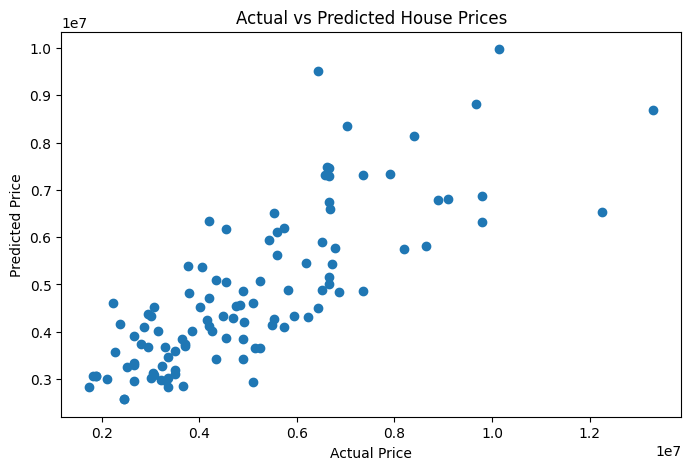

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred_rf)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

Task 5: Model Evaluation & Conclusion

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("LINEAR REGRESSION RESULTS")

print("MAE:",
      mean_absolute_error(y_test, y_pred_lr))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, y_pred_lr)))

print("R2 Score:",
      r2_score(y_test, y_pred_lr))

LINEAR REGRESSION RESULTS
MAE: 970043.4039201636
RMSE: 1324506.9600914386
R2 Score: 0.6529242642153184


In [ ]:
print("RANDOM FOREST RESULTS")

print("MAE:",
      mean_absolute_error(y_test, y_pred_rf))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, y_pred_rf)))

print("R2 Score:",
      r2_score(y_test, y_pred_rf))

RANDOM FOREST RESULTS
MAE: 1021546.0353211008
RMSE: 1400565.9728553821
R2 Score: 0.611918531405699


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

comparison_table = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf))
    ],
    'R2 Score': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf)
    ]
})

comparison_table

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.021546e+06,1.400566e+06,0.611919


# Insights & summary
The House Price Prediction project provided valuable insights into the factors that influence residential property prices. Through exploratory data analysis, it was observed that features such as area, number of bathrooms, number of stories, and parking availability had the strongest impact on house prices. The visualizations revealed a positive relationship between house area and price, indicating that larger houses generally command higher market values. Two machine learning models, Linear Regression and Random Forest Regressor, were trained and evaluated using MAE, RMSE, and R² Score metrics. The Linear Regression model achieved an R² Score of 0.6529, meaning it was able to explain approximately 65% of the variation in house prices and provide reasonably accurate predictions. An interesting observation was that some houses with similar areas had different prices, suggesting that additional amenities and property characteristics also influence value. Among the evaluated models, Linear Regression outperformed Random Forest by achieving lower prediction errors and a higher R² Score. Based on these findings, real estate businesses should focus on key features such as property size, bathrooms, and parking facilities when pricing properties and making investment decisions.

